In [ ]:
# import library
import pandas as pd
# loading  heart disease dataset
df=pd.read_csv("heart_disease_uci.csv")

In [ ]:
#printing first 5 rows data
df.head(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [ ]:
# df.info it show us how many non null values are in the datasets well as column data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
# sum up all the null values in all column and show their column null values count
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [ ]:
# handling missing values on numerical column by using mean and on categorical column by using  mode 
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].mean())
df['chol'] = df['chol'].fillna(df['chol'].mean())
df['fbs']=df['fbs'].fillna(df['fbs'].mode()[0])
df['restecg']=df['restecg'].fillna(df['restecg'].mode()[0])
df['thalch']=df['thalch'].fillna(df['thalch'].mode()[0])
df['exang']=df['exang'].fillna(df['exang'].mode()[0])
df['restecg']=df['restecg'].fillna(df['restecg'].mode()[0])
df['thalch']=df['thalch'].fillna(df['thalch'].mean())
df['exang']=df['exang'].fillna(df['exang'].mode()[0])
df['oldpeak']=df['oldpeak'].fillna(df['oldpeak'].mean())
df['ca']=df['ca'].fillna(df['ca'].mean())
df['thal']=df['thal'].fillna(df['thal'].mode()[0])
df['slope']=df['slope'].fillna(df['slope'].mode()[0])

C:\Users\PMLS\AppData\Local\Temp\ipykernel_24136\203729648.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs']=df['fbs'].fillna(df['fbs'].mode()[0])
C:\Users\PMLS\AppData\Local\Temp\ipykernel_24136\203729648.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang']=df['exang'].fillna(df['exang'].mode()[0])


In [ ]:
# impoting label encoder from scikit learn preprocessing which help to transform categorical column into numeric
from sklearn.preprocessing import LabelEncoder
categorical_cols = [
    'sex',
    'dataset',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'thal'
]
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [39]:
import matplotlib.pyplot as plt

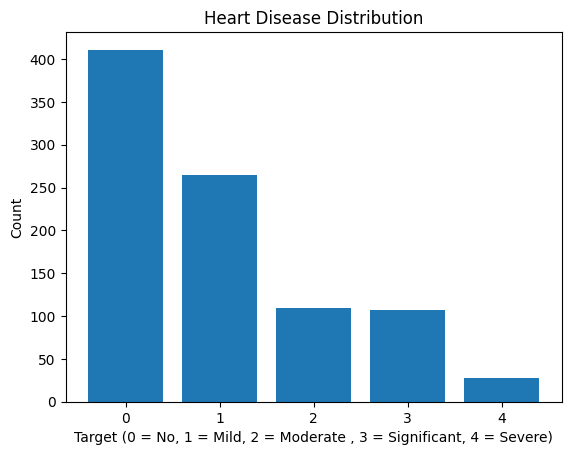

In [49]:
# num distribuion
counts = df['num'].value_counts()
plt.bar(counts.index, counts.values)
plt.title("Heart Disease Distribution")
plt.xlabel('Target (0 = No, 1 = Mild, 2 = Moderate , 3 = Significant, 4 = Severe)')
plt.ylabel("Count")
plt.show()

->Most patients have no heart disease (Class 0).

Class 0 has the highest count (around 410 patients).

->Mild heart disease (Class 1) is the second most common category.

Around 260 patients fall into this category.

->Moderate and Significant heart disease (Classes 2 and 3) occur less frequently.

Each has roughly 100–110 patients.

->Severe heart disease (Class 4) is the rarest category.

Only about 25–30 patients belong to this class.

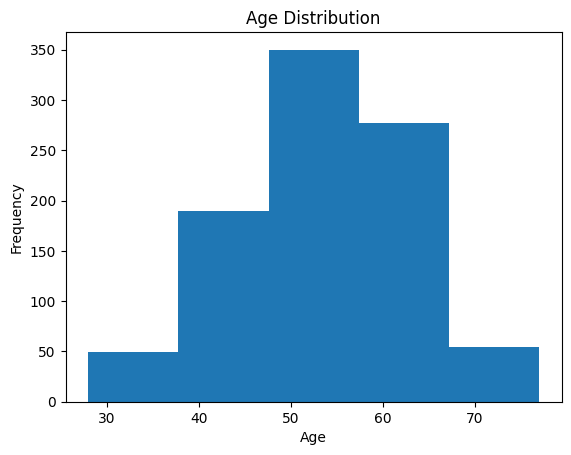

In [48]:
plt.hist(df['age'], bins=5)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Most patients are in the 50–60 age group, followed by 60–70 years. The 40–50 age group has a moderate frequency, while patients below 40 and above 70 are less common in the dataset.

Check which chest pain type is most common among heart disease patients.

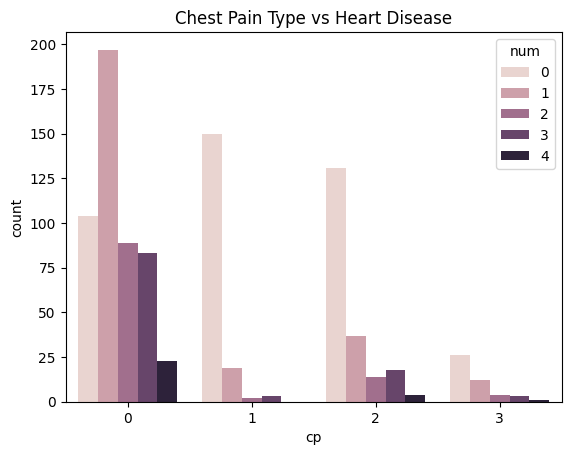

In [65]:
import seaborn as sns

sns.countplot(x='cp', hue='num', data=df)


plt.title('Chest Pain Type vs Heart Disease')
plt.show()


X-axis (cp) = Chest Pain Type
0 = Typical Angina
1 = Atypical Angina
2 = Non-anginal Pain
3 = Asymptomatic


Colors (num) = Heart Disease Severity
0 = No Heart Disease
1 = Mild
2 = Moderate
3 = Significant
4 = Severe

In [70]:
# selecting feature which we give as input (x) and on the basis its predict y
x = df.drop('num', axis=1)
y = df['num']  

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)

# 4. Transform test data (NO fitting here)
X_test = scaler.transform(X_test)
LogisticRegression_model=LogisticRegression(max_iter=10000)

In [75]:
LogisticRegression_model.fit(X_train, y_train)
y_pred = LogisticRegression_model.predict(X_test)


In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.5543478260869565
Precision: 0.48634390350343043
Recall   : 0.5543478260869565
F1 Score : 0.5061603351061065

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.92      0.78        75
           1       0.46      0.48      0.47        54
           2       0.22      0.08      0.12        25
           3       0.31      0.19      0.24        26
           4       0.00      0.00      0.00         4

    accuracy                           0.55       184
   macro avg       0.34      0.33      0.32       184
weighted avg       0.49      0.55      0.51       184


Confusion Matrix:
[[69  5  1  0  0]
 [22 26  2  4  0]
 [ 5 13  2  5  0]
 [ 5 12  3  5  1]
 [ 1  0  1  2  0]]


In [78]:
from sklearn.metrics import roc_auc_score

y_prob = LogisticRegression_model.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class='ovr',
    average='weighted'
)

print("Multiclass ROC-AUC:", roc_auc)

Multiclass ROC-AUC: 0.8091595473968596


In [80]:

feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': LogisticRegression_model.coef_[0]
})

feature_importance['Importance'] = abs(feature_importance['Coefficient'])

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

    Feature  Coefficient  Importance
0        id    -0.977432    0.977432
11  oldpeak    -0.790257    0.790257
3   dataset     0.685220    0.685220
13       ca    -0.567427    0.567427
2       sex    -0.544593    0.544593
6      chol     0.471508    0.471508
4        cp     0.458767    0.458767
10    exang    -0.380663    0.380663
14     thal    -0.239588    0.239588
9    thalch     0.229391    0.229391


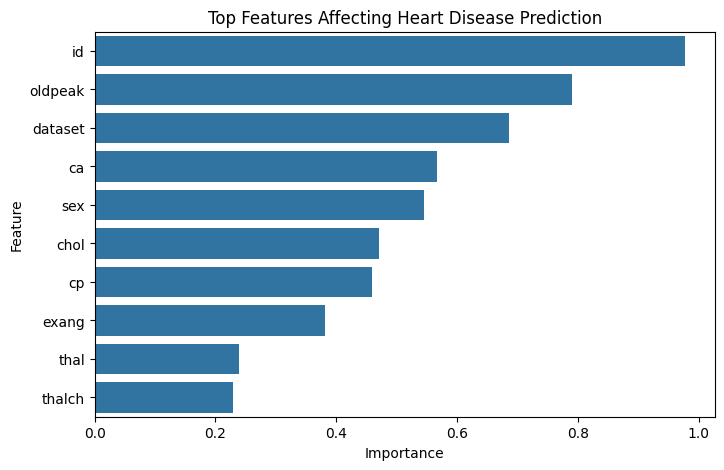

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',

    data=feature_importance.head(10)
)
plt.title('Top Features Affecting Heart Disease Prediction')

plt.show()